# *BigMart Sales Data*


In [62]:
# Import necessary Packages
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer


from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [63]:
# Upload the Data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

1. Data Preprocessing


In [ ]:
# get to know what we are dealing with
print(f'train data shape: {train.shape}')
print(f'test data shape: {test.shape}')
print(f'data description: {train.describe()}:')


train data shape: (8523, 12)
test data shape: (5681, 11)
data description:        Item_Weight  Item_Visibility     Item_MRP  Outlet_Establishment_Year  \
count  7060.000000      8523.000000  8523.000000                8523.000000   
mean     12.857645         0.066132   140.992782                1997.831867   
std       4.643456         0.051598    62.275067                   8.371760   
min       4.555000         0.000000    31.290000                1985.000000   
25%       8.773750         0.026989    93.826500                1987.000000   
50%      12.600000         0.053931   143.012800                1999.000000   
75%      16.850000         0.094585   185.643700                2004.000000   
max      21.350000         0.328391   266.888400                2009.000000   

       Item_Outlet_Sales  
count        8523.000000  
mean         2181.288914  
std          1706.499616  
min            33.290000  
25%           834.247400  
50%          1794.331000  
75%          3101.296400

In [ ]:
print(f'data information: {train.info}')


data information: <bound method DataFrame.info of      Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0              FDA15        9.300          Low Fat         0.016047   
1              DRC01        5.920          Regular         0.019278   
2              FDN15       17.500          Low Fat         0.016760   
3              FDX07       19.200          Regular         0.000000   
4              NCD19        8.930          Low Fat         0.000000   
...              ...          ...              ...              ...   
8518           FDF22        6.865          Low Fat         0.056783   
8519           FDS36        8.380          Regular         0.046982   
8520           NCJ29       10.600          Low Fat         0.035186   
8521           FDN46        7.210          Regular         0.145221   
8522           DRG01       14.800          Low Fat         0.044878   

                  Item_Type  Item_MRP Outlet_Identifier  \
0                     Dairy  249.8092 

In [71]:
print(f'How it looks like: \n{train.sample(5)}')

How it looks like: 
     Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
1753           FDT24        12.35              reg         0.186148   
2854           NCO05         7.27          Low Fat         0.046559   
3674           FDF52          NaN          Low Fat         0.066460   
8385           NCK53        11.60          Low Fat         0.037734   
1113           FDB21          NaN          Low Fat         0.000000   

                  Item_Type  Item_MRP Outlet_Identifier  \
1753           Baking Goods   78.2328            OUT049   
2854     Health and Hygiene  100.5384            OUT046   
3674           Frozen Foods  184.2292            OUT027   
8385     Health and Hygiene   98.1042            OUT018   
1113  Fruits and Vegetables  242.9854            OUT027   

      Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
1753                       1999      Medium               Tier 1   
2854                       1997       Small               Tier

In [78]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train.isnull().sum()
test.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [ ]:
# Unique values for each feature
numeric_features = ["Item_Weight", "Item_Visibility",
"Item_MRP", "Outlet_Establishment_Year"]
categorical_features = ["Item_Fat_Content", "Item_Type",
"Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]

for feature in categorical_features:
    unique_values = train[feature].unique()
    print(f"Column: {feature}")
    print(f"Unique values: {unique_values}\n")

Column: Item_Fat_Content
Unique values: ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']

Column: Item_Type
Unique values: ['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']

Column: Outlet_Size
Unique values: ['Medium' nan 'High' 'Small']

Column: Outlet_Location_Type
Unique values: ['Tier 1' 'Tier 3' 'Tier 2']

Column: Outlet_Type
Unique values: ['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']



In [ ]:
# We need to fix Item_Fat_Content because some values are the same

train = train.replace({'Item_Fat_Content': {'low fat':'Low Fat' ,'LF': 'Low Fat', 'reg':'Regular'}})
test = test.replace({'Item_Fat_Content': {'low fat':'Low Fat' ,'LF': 'Low Fat', 'reg':'Regular'}})
train['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [ ]:
# fix null values
imputer1 = SimpleImputer(strategy='most_frequent')
train['Outlet_Size'] = imputer1.fit_transform(train[['Outlet_Size']]).ravel()
test['Outlet_Size'] = imputer1.transform(test[['Outlet_Size']]).ravel()

# For numerical column (Item_Weight)
imputer2 = SimpleImputer(strategy='median')
train['Item_Weight'] = imputer2.fit_transform(train[['Item_Weight']]).ravel()
test['Item_Weight'] = imputer2.transform(test[['Item_Weight']]).ravel()

In [ ]:
train.isnull().sum()
test.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

In [ ]:
# Train Test Split
X = train.drop('Item_Outlet_Sales', axis=1)
y = train['Item_Outlet_Sales']

X_train, X_val, y_train, y_val = train_test_split(X, y,
test_size=0.2, random_state=42)

# Handling outliers
Q1 = X_train[numeric_features].quantile(0.25)
Q3 = X_train[numeric_features].quantile(0.75)
IQR = Q3 - Q1

X_train[numeric_features] = X_train[numeric_features].clip(
    lower=Q1 - 1.5*IQR,
    upper=Q3 + 1.5*IQR,
    axis=1
)

In [ ]:
# Manually remove the feature that seems unrelated
drop_features = ['Item_Identifier', 'Outlet_Identifier']
X_train = X_train.drop(drop_features, axis=1)
X_val = X_val.drop(drop_features, axis=1)
test = test.drop(drop_features, axis=1)

In [ ]:
# Normalization and Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
,  remainder='drop')

# Fit on Training Data
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
test = preprocessor.transform(test)

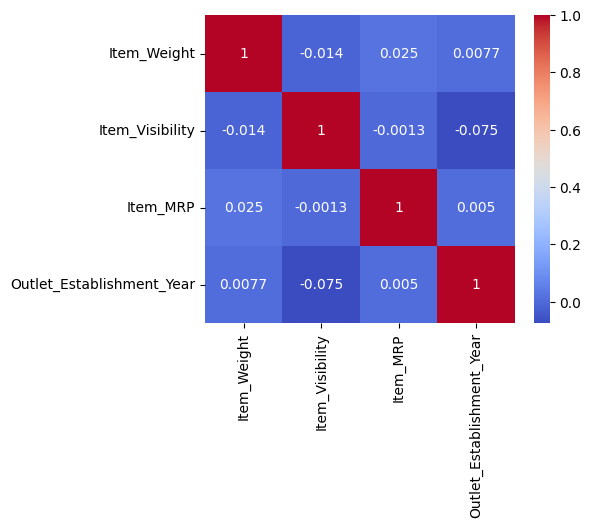

In [ ]:
# Correlation Matrix
corr_matrix = train[numeric_features].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

2. Model Selection

In [ ]:
# make an object from each model and fit on the data
rf = RandomForestRegressor().fit(X_train, y_train)
xgb = XGBRegressor().fit(X_train, y_train)
knn = KNeighborsRegressor().fit(X_train, y_train)

Models = [rf, xgb, knn]

for model in Models:
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    print(f"{model.__class__.__name__}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}\n")

RandomForestRegressor:
  RMSE: 1094.63
  R²: 0.5592

XGBRegressor:
  RMSE: 1126.14
  R²: 0.5334

KNeighborsRegressor:
  RMSE: 1166.29
  R²: 0.4995



In [ ]:
# Cross Validation
for model in Models:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    print(f'{model.__class__.__name__}:')
    print(f' Avg RMSE: {rmse_scores.mean()} (±{rmse_scores.std():.2f})\n')


RandomForestRegressor:
 Avg RMSE: 1148.699118876399 (±12.11)

XGBRegressor:
 Avg RMSE: 1203.9894989643883 (±23.06)

KNeighborsRegressor:
 Avg RMSE: 1216.0716642665698 (±32.57)



In [ ]:
# Hyperprameter Tuning
param_grid = {
    'n_estimators':randint(50,200),
    'max_depth':[None,10,20],
    'min_samples_split':randint(2,6)
}

RandSearch = RandomizedSearchCV(RandomForestRegressor(), n_iter=4,
param_distributions= param_grid, cv=3,n_jobs=-1, scoring='neg_mean_squared_error')
RandSearch.fit(X_train, y_train)
print("Best RMSE: ", RandSearch.best_params_)

Best RMSE:  {'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 143}


In [ ]:
#retrain the model
best_rf = RandomForestRegressor(
    n_estimators=RandSearch.best_params_['n_estimators'],
    max_depth= RandSearch.best_params_['max_depth'],
    min_samples_split=RandSearch.best_params_['min_samples_split'],
    random_state=42
)
best_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=143, random_state=42)

In [ ]:
# Evaluate on Validation set
y_pred = best_rf.predict(X_val)
r2 = r2_score(y_val, y_pred)
print(f"Final RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Final RMSE: 1166.29
R² Score: 0.6004


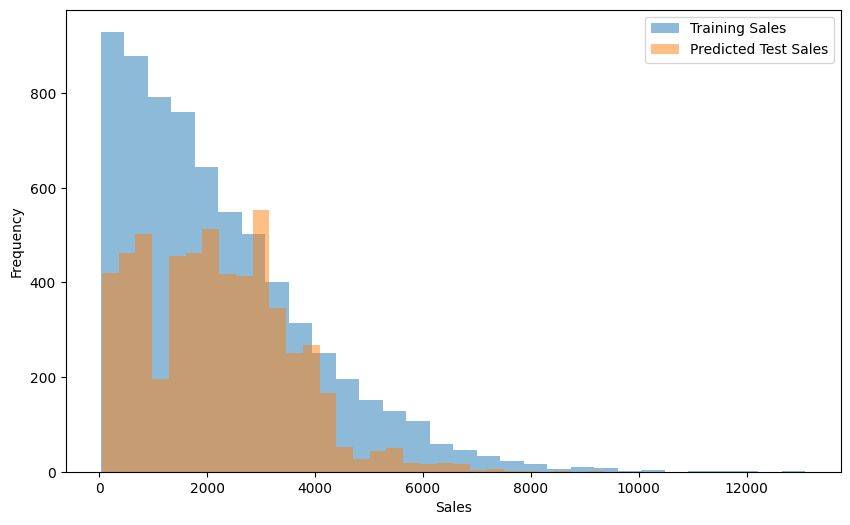

In [ ]:
# Predictions
test_predictions = best_rf.predict(test)
pd.DataFrame({'Predicted_Sales': test_predictions}).to_csv('test_predictions.csv', index=False)

# Compare the two distribution
plt.figure(figsize=(10, 6))
plt.hist(y_train, bins=30, alpha=0.5, label='Training Sales')
plt.hist(test_predictions, bins=30, alpha=0.5, label='Predicted Test Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Final Result Explanation
To develop our sales prediction model, we strategically split our labeled training data into separate training (80%) and validation (20%) sets. This approach was necessary because the test set provided lacked ground truth labels.
We conducted a comprehensive evaluation of three machine learning models:
1. Random Forest Regressor
2. XGBoost Regressor
3. K-Nearest Neighbors Regressor
Through this comparative analysis, the Random Forest model demonstrated superior performance, achieving the most accurate predictions on our validation set.

We further refined the Random Forest model through hyperparameter tuning, which yielded our final configuration:
* Number of estimators: 143
* Maximum depth: 10
* Minimum samples split: 4

The optimized model achieved an R² score of 0.60 on the validation data, explaining approximately 60% of the variance in sales figures. While we explored various improvements, the inherent limitations of the dataset constrained further enhancements to this performance metric.